# 1 Zeiten Basemodell

- Für die Double Werte auf dem Arduino werden 15 signifikante Stellen verwendet
  - Double stellt 52 Bits für die Mantisse bereit -> 2^52 = 4 503 599 627 370 500 
  - Mit 15 signifikanten Stellen sind Zahlen bis 999 999 999 999 999 möglich

## 1.0 Sketch / Wie die Zeiten genommen wurden

In [ ]:
#define INPUT_SIZE // [Anzahl Merkmale]
#define OUTPUT_SIZE // [Anzahl Klassen] 
#define BAUD 9600

double input[INPUT_SIZE];
double output[OUTPUT_SIZE];
unsigned long duration;
unsigned long start;
unsigned long end;

// Die Modellbezogenen Funktionen wurden hier weggelassen, da diese modellspezifisch sind
// Die Zeitnahme erfolgt jedoch immer auf die gleiche Art und Weise
// Der Funktionsaufruf ist in diesem Code-Snippet jedoch enthalten

void setup() {
  Serial.begin(BAUD);
  randomSeed(0);        // Fuer Reproduzierbarkeit
}

void loop() {
  duration = 0;
  for(int i=0; i<1000; i++) {
    fillArray(input);
    start = micros();
    // start = millis();
    score(input, output);
    end = micros();
    // end = millis();
    duration += (end - start);
  }
  Serial.print(duration);
  Serial.print(", ");
}

void fillArray(double * array) {
  long randomVal;
  double randomDec;
  
  for(int i = 0; i<INPUT_SIZE; i++){
    randomVal = random(-200000,200001);
    randomDec = (double)randomVal / 10000;
    array[i] = randomDec;
  }
}


## 1.1 Gyro

In [ ]:
Die Geschwindigkeit bzw. Inferenzdauer 

### 1.1.1 Millisekunden (langsamer)

In [ ]:
base_gyro_millis = [
    4206, 4184, 4189, 4204, 4204, 4188, 4181, 4190, 4200, 4196,
    4178, 4198, 4198, 4194, 4189, 4185, 4210, 4198, 4195, 4182, 
    4203, 4207, 4193, 4188, 4193, 4199, 4189, 4182, 4192, 4209, 
    4196, 4192, 4199, 4194, 4196, 4196, 4196, 4213, 4206, 4202, 
    4182, 4207, 4194, 4176, 4177, 4207, 4207, 4207, 4186, 4186, 
    ]

print(len(base_gyro_millis))

print(f'Minimale Inferenzdauer: \t\t\t{min(base_gyro_millis)} ms')
print(f'Maximale Inferenzdauer: \t\t\t{max(base_gyro_millis)} ms')
print(f'Durchschnittliche Inferenzdauer: \t\t{sum(base_gyro_millis)/len(base_gyro_millis)} ms')
print(f'Durchschnittliche Inferenzdauer pro Instanz: \t{(sum(base_gyro_millis)/len(base_gyro_millis))/1000} ms')
print(f'Inferenzen pro Sekunde: \t\t\t{1000000/((sum(base_gyro_millis)/len(base_gyro_millis))/1000)}')
print(f'Inferenzen pro Sekunde (gerundet): \t\t{int(1000/((sum(base_gyro_millis)/len(base_gyro_millis))/1000))}')

print("\n!!! MILLISEKUNDEN ZU ERMITTELN DAUERT LÄNGER AUF DEM ARDUINO !!!")

50
Minimale Inferenzdauer: 			4176 ms
Maximale Inferenzdauer: 			4213 ms
Durchschnittliche Inferenzdauer: 		4194.86 ms
Durchschnittliche Inferenzdauer pro Instanz: 	4.194859999999999 ms
Inferenzen pro Sekunde: 			238386.97834969466
Inferenzen pro Sekunde (gerundet): 		238

!!! MILLISEKUNDEN ZU ERMITTELN DAUERT LÄNGER AUF DEM ARDUINO !!!


### 1.1.1 µ-Sekunden

In [39]:
base_gyro_micros = [
    4060798, 4062132, 4060959, 4064614, 4063872, 4066401, 4064696, 4064284, 4065308, 4062355, 
    4065072, 4061462, 4061728, 4064475, 4060684, 4057053, 4062696, 4062622, 4061955, 4062623, 
    4063950, 4059761, 4058905, 4065272, 4063534, 4058903, 4065599, 4062075, 4061944, 4063155, 
    4061684, 4065621, 4062188, 4062671, 4061120, 4067814, 4062747, 4061193, 4065218, 4064752, 
    4065815, 4062166, 4065957, 4059836, 4058773, 4061303, 4062596, 4064203, 4062804, 4061171
    ]

print(len(base_gyro_micros))

print(f'Minimale Inferenzdauer: \t\t\t{min(base_gyro_micros)} µs')
print(f'Maximale Inferenzdauer: \t\t\t{max(base_gyro_micros)} µs')
print(f'Durchschnittliche Inferenzdauer: \t\t{sum(base_gyro_micros)/len(base_gyro_micros)} µs')
print(f'Durchschnittliche Inferenzdauer pro Instanz: \t{(sum(base_gyro_micros)/len(base_gyro_micros))/1000} µs')
print(f'Inferenzen pro Sekunde: \t\t\t{1000000/((sum(base_gyro_micros)/len(base_gyro_micros))/1000)}')
print(f'Inferenzen pro Sekunde (gerundet): \t\t{int(1000000/((sum(base_gyro_micros)/len(base_gyro_micros))/1000))}')

50
Minimale Inferenzdauer: 			4057053 µs
Maximale Inferenzdauer: 			4067814 µs
Durchschnittliche Inferenzdauer: 		4062770.38 µs
Durchschnittliche Inferenzdauer pro Instanz: 	4062.77038 µs
Inferenzen pro Sekunde: 			246.13746445596564
Inferenzen pro Sekunde (gerundet): 		246


## 1.2 Harus

In [ ]:
base_harus_micros = [
    4800518, 4800307, 4800508, 4799054, 4802106, 4800131, 4799620, 4799332, 4802152, 4802960, 
    4799278, 4801756, 4802600, 4801237, 4803206, 4799958, 4801087, 4800965, 4804529, 4800686, 
    4801551, 4800663, 4801272, 4802217, 4801075, 4801995, 4802157, 4800523, 4799169, 4801614, 
    4802980, 4803860, 4801878, 4798048, 4801675, 4799351, 4801220, 4800915, 4800814, 4804521, 
    4801008, 4798067, 4803456, 4800772, 4802118, 4802115, 4804179, 4798253, 4802477, 4800696
    ]

print(len(base_harus_micros))

print(f'Minimale Inferenzdauer: \t\t\t{min(base_harus_micros)} µs')
print(f'Maximale Inferenzdauer: \t\t\t{max(base_harus_micros)} µs')
print(f'Durchschnittliche Inferenzdauer: \t\t{sum(base_harus_micros)/len(base_harus_micros)} µs')
print(f'Durchschnittliche Inferenzdauer pro Instanz: \t{(sum(base_harus_micros)/len(base_harus_micros))/1000} µs')
print(f'Inferenzen pro Sekunde: \t\t\t{1000000/((sum(base_harus_micros)/len(base_harus_micros))/1000)}')
print(f'Inferenzen pro Sekunde (gerundet): \t\t{int(1000000/((sum(base_harus_micros)/len(base_harus_micros))/1000))}')

50
Minimale Inferenzdauer: 			4798048 µs
Maximale Inferenzdauer: 			4804529 µs
Durchschnittliche Inferenzdauer: 		4801252.58 µs
Durchschnittliche Inferenzdauer pro Instanz: 	4801.25258 µs
Inferenzen pro Sekunde: 			208.27898206513433
Inferenzen pro Sekunde (gerundet): 		208


## 1.3 Mushroom


In [6]:
base_mushroom_micros = [
    2959611, 2948299, 2953792, 2956912, 2964099, 2967792, 2952340, 2948886, 2961857, 2950536, 
    2970717, 2953493, 2959986, 2958252, 2956719, 2951790, 2955868, 2963159, 2956951, 2962360, 
    2950317, 2954283, 2953594, 2954307, 2962173, 2958301, 2969568, 2960417, 2951993, 2956142, 
    2960001, 2959470, 2963524, 2962423, 2958874, 2958074, 2956744, 2949139, 2952669, 2952765, 
    2962543, 2948422, 2955580, 2959646, 2957185, 2969083, 2956859, 2956449, 2958839, 2954095
    ]

print(f'Minimale Inferenzdauer: \t\t\t{min(base_mushroom_micros)} µs')
print(f'Maximale Inferenzdauer: \t\t\t{max(base_mushroom_micros)} µs')
print(f'Durchschnittliche Inferenzdauer: \t\t{sum(base_mushroom_micros)/len(base_mushroom_micros)} µs')
print(f'Durchschnittliche Inferenzdauer pro Instanz: \t{(sum(base_mushroom_micros)/len(base_mushroom_micros))/1000} µs')
print(f'Inferenzen pro Sekunde: \t\t\t{1000000/((sum(base_mushroom_micros)/len(base_mushroom_micros))/1000)}')
print(f'Inferenzen pro Sekunde (gerundet): \t\t{int(1000000/((sum(base_mushroom_micros)/len(base_mushroom_micros))/1000))}')

Minimale Inferenzdauer: 			2948299 µs
Maximale Inferenzdauer: 			2970717 µs
Durchschnittliche Inferenzdauer: 		2957537.96 µs
Durchschnittliche Inferenzdauer pro Instanz: 	2957.53796 µs
Inferenzen pro Sekunde: 			338.11907523242746
Inferenzen pro Sekunde (gerundet): 		338


# 2 Programm Space in Bytes Basemodelle

- Dynamic Memory unterscheidet sich hier nur auf Basis der Arraygrößen (und deren Datentypen)
- Percentage ist abgeschnitten und nicht gerundet!

**Boilerplate -> Leeres setup() und loop()**

|Storage                    |Used  |Maximum |Percentage|
|:--------------------------|:----:|-------:|---------:|
|Program Storage            |85264 |983040  |        8%|
|Dynamic Memory/Global vars |44552 |262144  |       16%|
|Left for local vars        | -    |217592  |       -  |

## 2.1 Gyro

**Modell + fillArray + input[6] + output[2]**

|Storage                    |Used  |Maximum |Percentage|
|:--------------------------|:----:|-------:|---------:|
|Program Storage            |190152|983040  |       19%|
|Dynamic Memory/Global vars |44616 |262144  |       17%|
|Left for local vars        | -    |217528  |       -  |

## 2.2 Harus

|Storage                    |Used  |Maximum|Percentage|
|:--------------------------|:----:|------:|---------:|
|Program Storage            |310664|983040 |       31%|
|Dynamic Memory/Global vars |49088 |262144 |       18%|
|Left for local vars        | -    |213056 |       -  |

## 2.3 Mushroom

|Storage                    |Used  |Maximum|Percentage|
|:--------------------------|:----:|------:|---------:|
|Program Storage            |302984|983040 |       30%|
|Dynamic Memory/Global vars |45592 |262144 |       17%|
|Left for local vars        | -    |216552 |       -  |


# 3 (S)RAM Messungen Basemodelle

[Arduino Docs: SRAM Memory Measurement](https://docs.arduino.cc/learn/programming/memory-guide/#sram-memory-measurement)

## 3.1 Gyro

## 3.2 Harus

561*8 = 4488 Bytes / Input

Left: 213056 Bytes left

Undefinierte Menge für Serial.prints (Angeblich RAM-heavy)

-----------

Ohne Inputs:
44552

Mit 20 Inputs:
134360 -> 20*(561*8)=89760  (134360 - 89760 = 44600)

Mit 40 Inputs:
224120 -> 40*(561*8)=179520 (224120 -179520 = 44600)

Mit 48 Inputs:
260024 -> 48*(561*8)=215424 (260024 - 215424 = 44600)

Mit 50 Inputs:
Compilation failed: cannot move location counter backwards (from 20041cc8 to 2003fc00) -> 50*(561*8)= 224400
(224400 + 44600 = 269000 > "Maximum is 262144 bytes"

Annahme: Output wird ignoriert, wenn ich keine die Score-Funktion gar nicht nutze!

Größe Output: double Output[6]: 6*8Bytes = 48 Bytes
Ram-Verbrauch nach Abzug der Inputs - Ram-Verbrauch ohne Inputs = 44600 - 44552 = 48

Liegt zumindes nahe

----------------

## 3.3 Mushroom

# 4 Performance

## 4.1 Gyro


              precision    recall  f1-score   support

 0: standing   0.120690  0.865979  0.211854        97
  1: walking   0.997259  0.885436  0.938027      5342

    accuracy                       0.885089      5439
   macro avg   0.558974  0.875708  0.574940      5439
weighted avg   0.981626  0.885089  0.925076      5439

0.8757077738365877


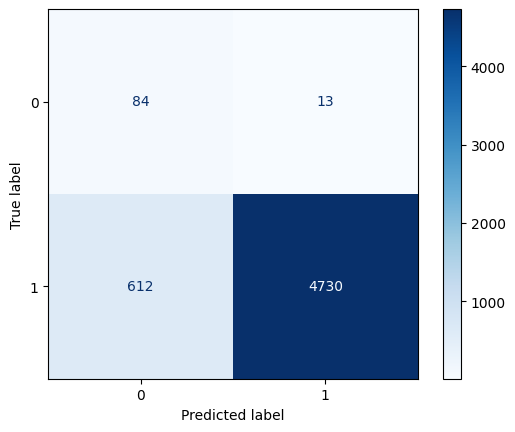

In [ ]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm

port_scores = pd.read_csv("datasets/port-scores/base_gyro_scores.csv")
ypred = port_scores["class"]
ytrue = pd.read_csv("datasets/gyro/ytest.csv")['Activity']

skm.ConfusionMatrixDisplay.from_predictions(ytrue,ypred, cmap="Blues" ,values_format='d')
print(skm.classification_report(ytrue,ypred,labels=[0,1], target_names=['0: standing','1: walking'], digits=6))
print(skm.balanced_accuracy_score(ytrue,ypred))



|Leistungskennzahlen AGMP-Port ||
|:--------------------------|-----:|
|Sensitivität           |0,885436|
|Spezifität             |0,865979|
|Präzision              |0,997259|
|F1 Wert                |0,938026|
|Balancierte Genauigkeit|0.875708|

(Identisch mit Original)

## 4.2 Harus

              precision    recall  f1-score   support

           0   0.989761  0.989761  0.989761       293
           1   0.992453  1.000000  0.996212       263
           2   0.987395  0.983264  0.985325       239
           3   0.976667  0.970199  0.973422       302
           4   0.975385  0.978395  0.976888       324
           5   1.000000  1.000000  1.000000       330

    accuracy                       0.986865      1751
   macro avg   0.986943  0.986936  0.986935      1751
weighted avg   0.986853  0.986865  0.986854      1751

0: TP 290, FP 3, TN 1455, FN 3
1: TP 263, FP 0, TN 1486, FN 2
2: TP 235, FP 4, TN 1509, FN 3
3: TP 293, FP 9, TN 1442, FN 7
4: TP 317, FP 7, TN 1419, FN 8
5: TP 330, FP 0, TN 1421, FN 0


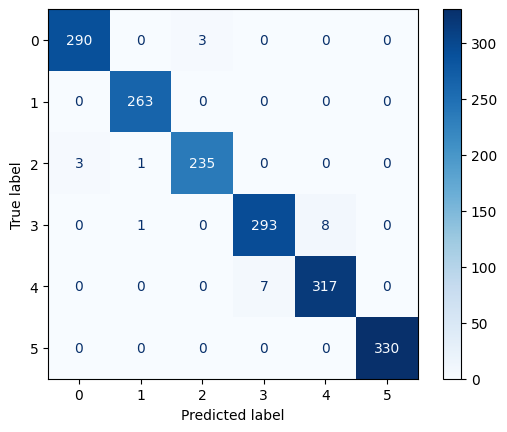

In [32]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm

def calculate_confusion_counts(ycompare, values):
    for val in values:
        tp = ycompare[(ycompare["true"] == val) & (ycompare["predicted"] == val)].shape[0]
        fp = ycompare[(ycompare["true"] == val) & (ycompare["predicted"] != val)].shape[0]
        tn = ycompare[(ycompare["true"] != val) & (ycompare["predicted"] != val)].shape[0]
        fn = ycompare[(ycompare["true"] != val) & (ycompare["predicted"] == val)].shape[0]

        print(f'{val}: TP {tp}, FP {fp}, TN {tn}, FN {fn}')

port_scores = pd.read_csv("datasets/port-scores/base_harus_scores.csv")
ypred = port_scores["class"]
ytrue = pd.read_csv("datasets/harus/ytest.csv")['label']

ycompare = pd.concat([ytrue,ypred],axis=1)
ycompare = ycompare.rename(columns={"label": "true", "class": "predicted"})

calculate_confusion_counts(ycompare, [0,1,2,3,4,5])

tp0, tp1, tp2, tp3, tp4, tp5 = 290, 263, 235, 293, 317, 330
sumtp = tp0+tp1+tp2+tp3+tp4+tp5

fp0, fp1, fp2, fp3, fp4, fp5 = 3, 0, 4, 9, 7, 0
sumfp = fp0 + fp1 + fp2 + fp3 + fp4 + fp5

tn0, tn1, tn2, tn3, tn4, tn5 = 1455, 1486, 1509, 1442, 1419, 1421
sumtn = tn0 + tn1 + tn2 + tn3 + tn4 + tn5

fn0, fn1, fn2, fn3, fn4, fn5 = 3, 2, 3, 7, 8, 0
sumfn = fn0 + fn1 + fn2 + fn3 + fn4 + fn5

sens = sumtp/(sumtp + sumfp)
print(sens)

spec = sumtn/(sumtn + sumfn)
print(spec)

skm.ConfusionMatrixDisplay.from_predictions(ytrue,ypred, cmap="Blues" ,values_format='d')
print(skm.classification_report(ytrue,ypred,digits=6))
skm.accuracy_score(ytrue,ypred)

|Leistungskennzahlen HARUS-Port |        |
|:------------------------------|-------:|
|Sensitivität                   |0.986865|
|Spezifität                     |0.997373|
|Präzision                      |0.986853|
|F1 Wert                        |0.986854|
|Genauigkeit                    |0.986865|

Leichte Abweichungen (möglicherweise Aufgrund vom Verlust signifikanter Dezimalstellen)

Abweicher nochmal auf Arduino überprüfen!

## 4.3 Mushroom

              precision    recall  f1-score   support

           0   1.000000  1.000000  1.000000      4621
           1   1.000000  1.000000  1.000000      5761

    accuracy                       1.000000     10382
   macro avg   1.000000  1.000000  1.000000     10382
weighted avg   1.000000  1.000000  1.000000     10382



1.0

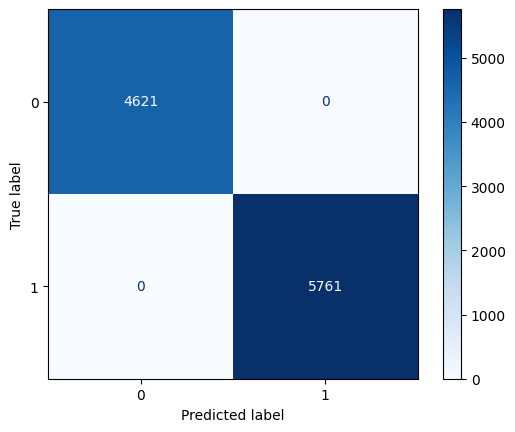

In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm

port_scores = pd.read_csv("datasets/port-scores/base_mushroom_scores_neu.csv")
ypred = port_scores["class"]
ytrue = pd.read_csv("datasets/mushroom/ytest.csv")['class']

skm.ConfusionMatrixDisplay.from_predictions(ytrue,ypred, cmap="Blues" ,values_format='d')
print(skm.classification_report(ytrue,ypred,digits=6))
skm.accuracy_score(ytrue,ypred)

Ja... ehm...

# Notizen